ValueError: stat: embedded null character in path

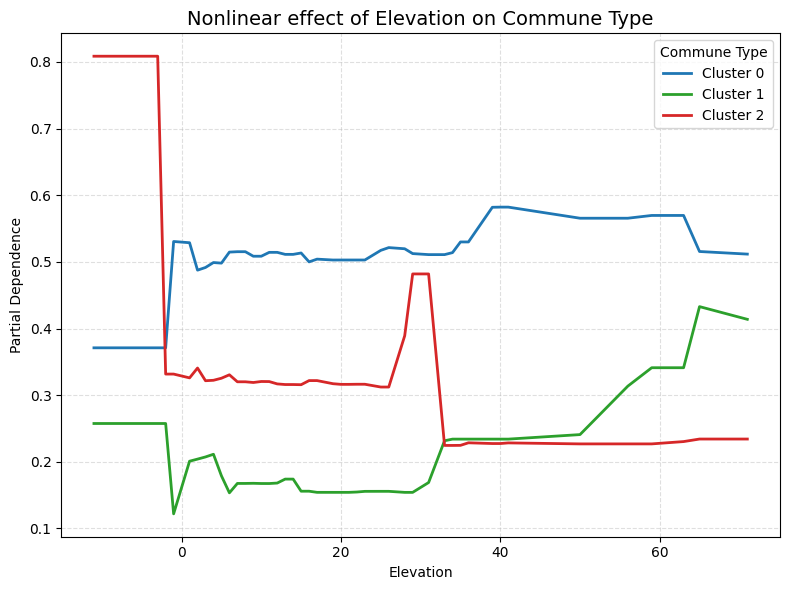

In [3]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from sklearn.inspection import partial_dependence
import shap


# === 1. 数据与变量定义 ===
independent_vars = [
    "Elevation", "Precipitation", "Temperature", "Wind",
    "Distance to canal", "Distance to railway", "Distance to ocean",
    "Distance to river", "Distance to highway", "Distance to central city"
]

dependent_vars = ["cluster"]  # 目标变量为聚类类型，Cluster 0, 1, 2

color_map = {
    0: "#1f77b4",    # Cluster 0 (蓝色)
    1: "#2ca02c",    # Cluster 1 (绿色)
    2: "#d62728"     # Cluster 2 (红色)
}

# === 2. 自定义绘图函数：每个特征与公社聚类的PDP图 ===
def plot_combined_pdp_for_feature(feature_name, df, independent_vars, dependent_vars):
    X = df[independent_vars]
    y = df[dependent_vars]

    plt.figure(figsize=(8, 6))
    plt.title(f"Nonlinear effect of {feature_name} on Commune Type", fontsize=14)

    for cluster in range(3):
        # 针对每个聚类训练模型
        y_cluster = (y == cluster).astype(int)  # 获取当前聚类的标签

        model = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
        model.fit(X, y_cluster)

        pdp_result = partial_dependence(model, X, features=[feature_name], kind='average')
        values = pdp_result["values"][0]
        averaged_effect = pdp_result["average"][0]

        plt.plot(values, averaged_effect, label=f"Cluster {cluster}", color=color_map[cluster], linewidth=2)

    plt.xlabel(feature_name)
    plt.ylabel("Partial Dependence")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(title="Commune Type")
    plt.tight_layout()
    plt.savefig(f"E:\00论文\heritage science\出图\PDP\pdp_combined_{feature_name}_commune.png", dpi=300)
    plt.show()

# === 3. 对每个自变量画合并图 ===
for var in independent_vars:
    plot_combined_pdp_for_feature(var, df, independent_vars, dependent_vars)


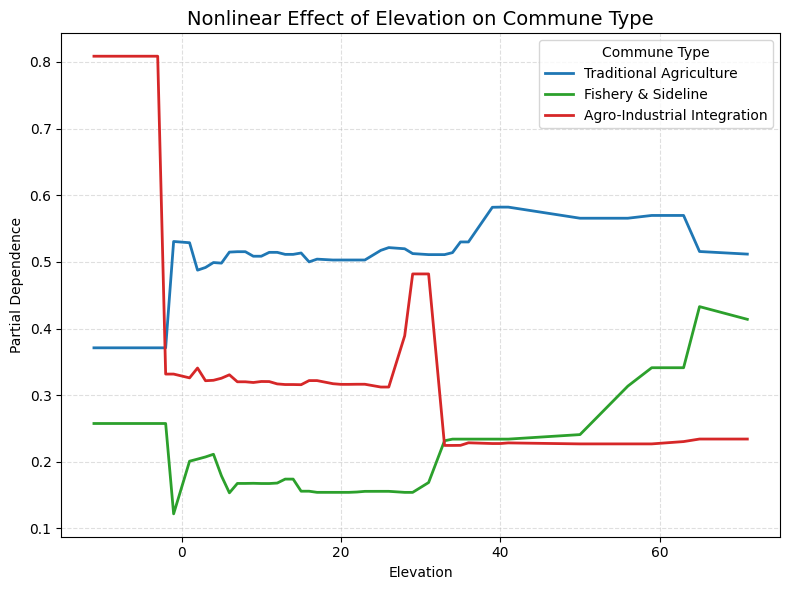

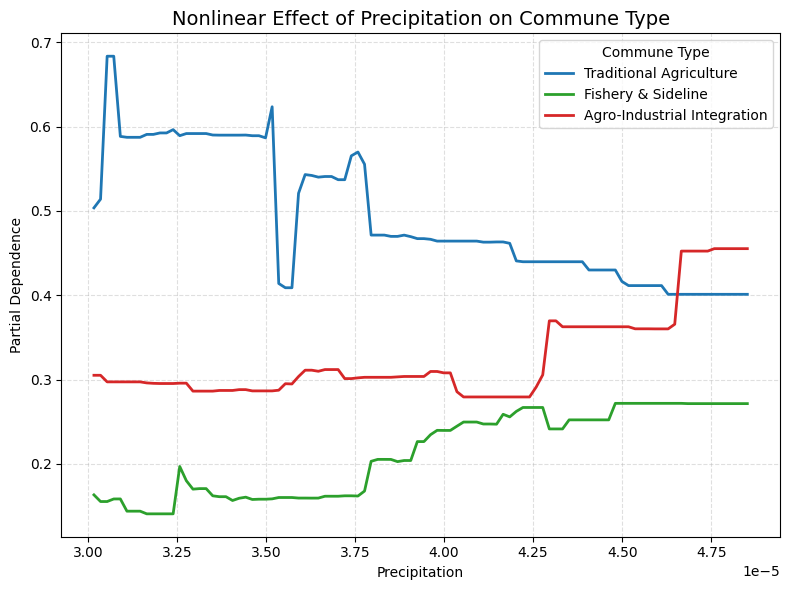

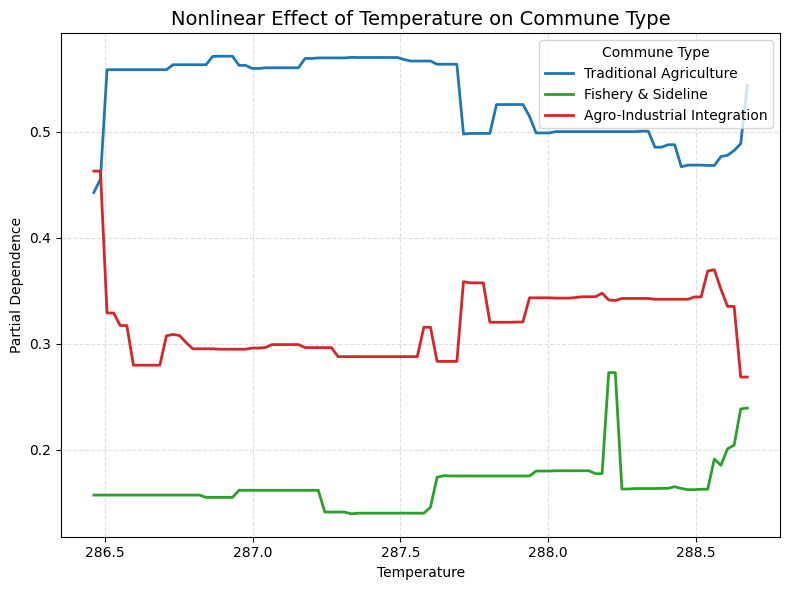

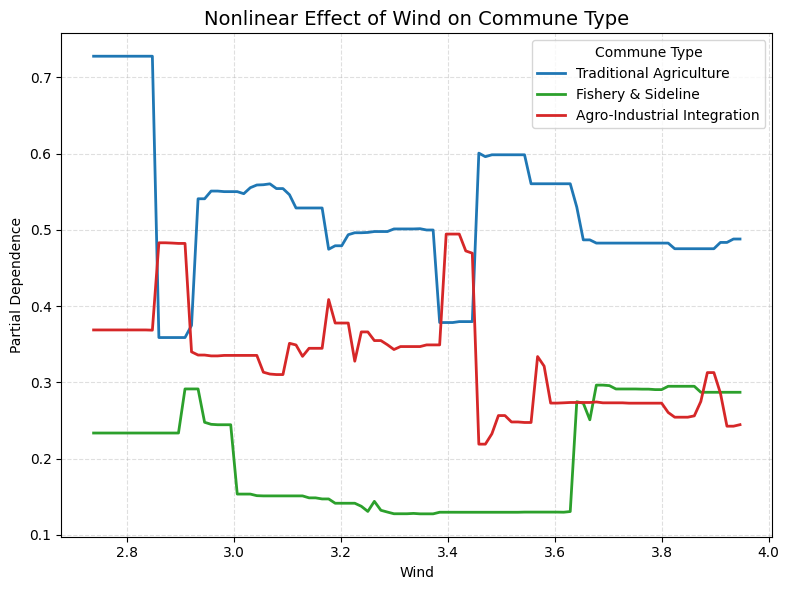

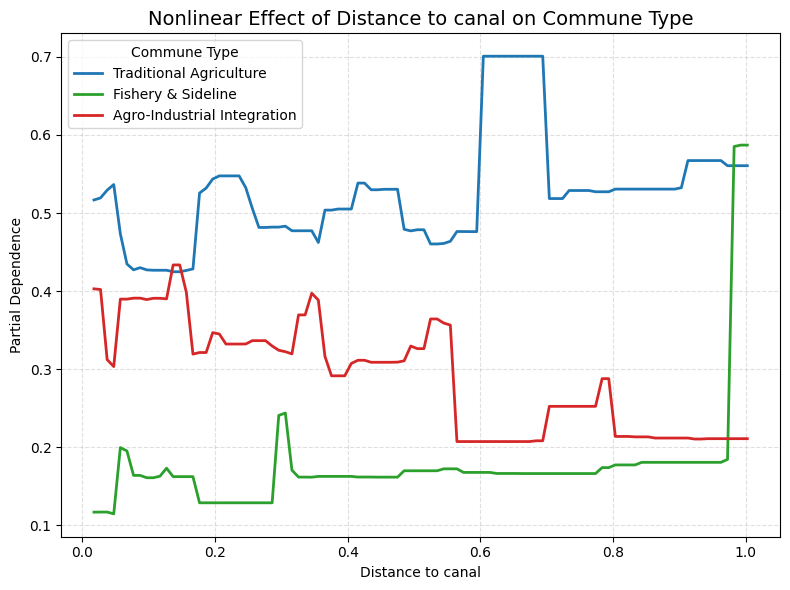

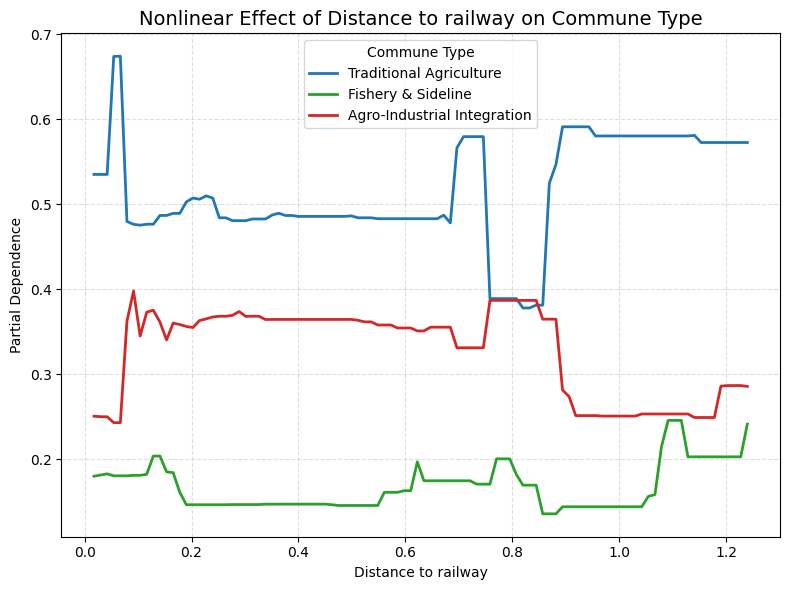

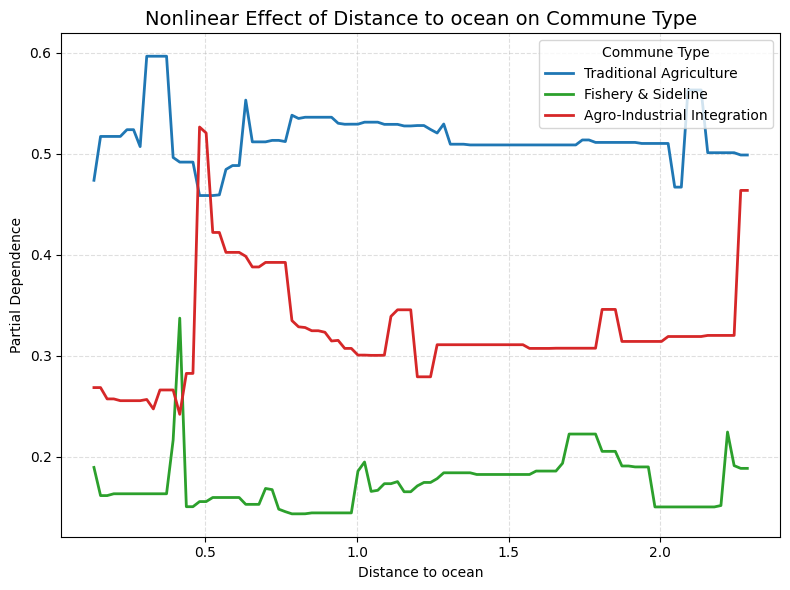

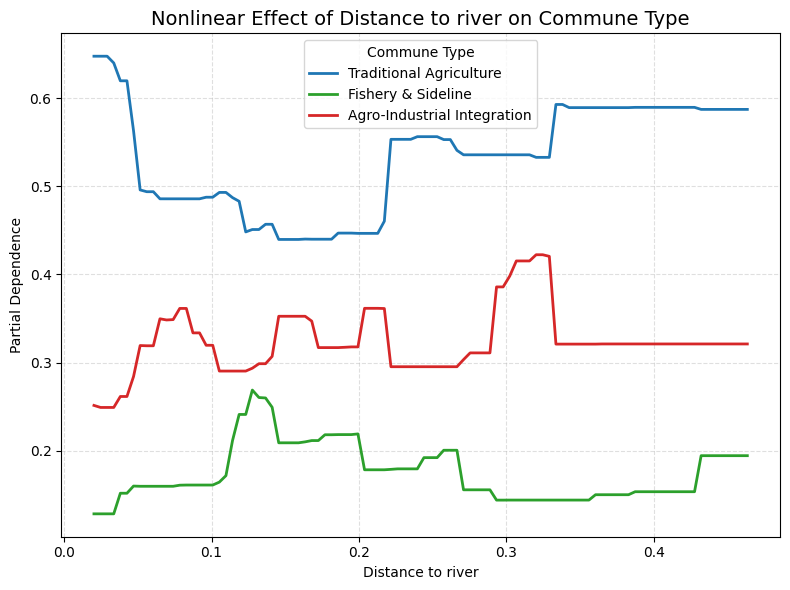

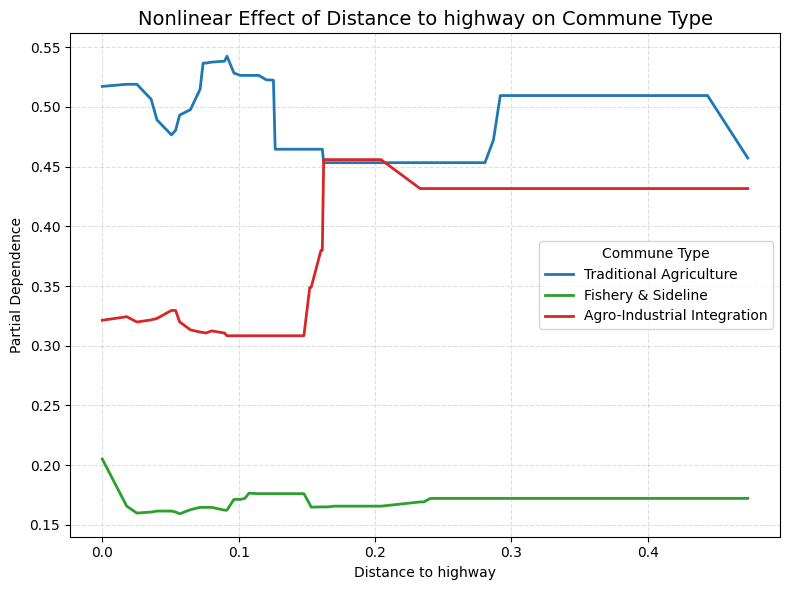

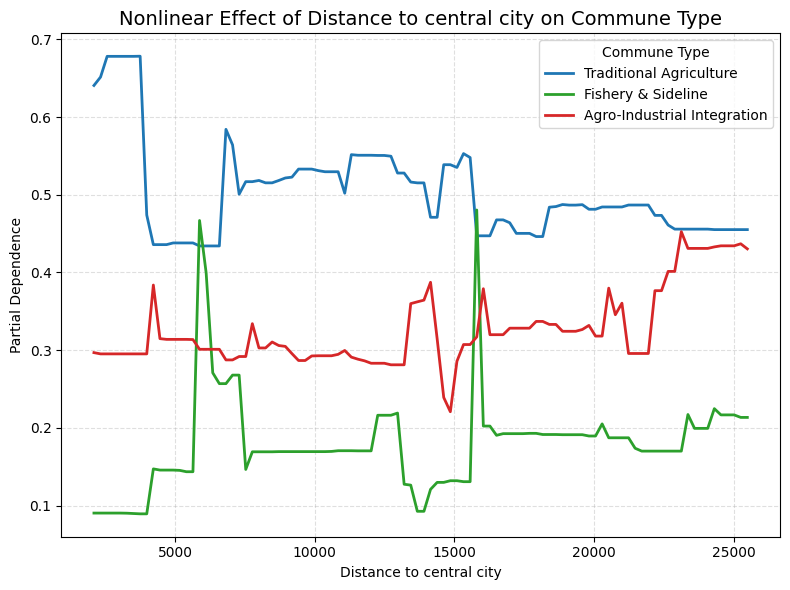

In [4]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from sklearn.inspection import partial_dependence
import shap


import pandas as pd
df = pd.read_csv(r"E:\00论文\heritage science\0630\Extract_commune_with_cluster.csv")  # 替换为你的真实路径

# === 1. 数据与变量定义 ===
independent_vars = [
    "Elevation", "Precipitation", "Temperature", "Wind",
    "Distance to canal", "Distance to railway", "Distance to ocean",
    "Distance to river", "Distance to highway", "Distance to central city"
]

dependent_vars = ["cluster"]  # 目标变量为聚类类型，Cluster 0, 1, 2

color_map = {
    0: "#1f77b4",    # 蓝色
    1: "#2ca02c",    # 绿色
    2: "#d62728"     # 红色
}

cluster_names = {
    0: "Traditional Agriculture",
    1: "Fishery & Sideline",
    2: "Agro-Industrial Integration"
}

# === 2. 自定义绘图函数：每个特征与公社聚类的PDP图 ===
def plot_combined_pdp_for_feature(feature_name, df, independent_vars, dependent_vars):
    X = df[independent_vars]
    y = df[dependent_vars]

    plt.figure(figsize=(8, 6))
    plt.title(f"Nonlinear Effect of {feature_name} on Commune Type", fontsize=14)

    for cluster in range(3):
        y_cluster = (y == cluster).astype(int)

        model = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
        model.fit(X, y_cluster)

        pdp_result = partial_dependence(model, X, features=[feature_name], kind='average')
        values = pdp_result["values"][0]
        averaged_effect = pdp_result["average"][0]

        label_name = cluster_names[cluster]
        plt.plot(values, averaged_effect, label=label_name, color=color_map[cluster], linewidth=2)

    plt.xlabel(feature_name)
    plt.ylabel("Partial Dependence")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(title="Commune Type")
    plt.tight_layout()
    plt.savefig(f"E:\\00论文\\heritage science\\出图\\PDP\\pdp_combined_{feature_name}_commune.png", dpi=600)
    plt.show()

# === 3. 对每个自变量画合并图 ===
for var in independent_vars:
    plot_combined_pdp_for_feature(var, df, independent_vars, dependent_vars)
